# Analisi dei Modelli PEFT (Soft Prompt / Prefix Tuning)
Questo notebook esegue l'analisi visiva e quantitativa dei token virtuali appresi durante l'addestramento, includendo l'analisi geometrica lineare (PCA) e non lineare (t-SNE), la similarità cosinale rispetto al vocabolario e il calcolo dell'entropia rinormalizzata delle mappe di attenzione.

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from trainer import prepare_data
from soft_ner_model import NERSoftPromptModel
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch.nn.functional as F
from seqeval.metrics import f1_score, classification_report
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.metrics.pairwise import cosine_similarity


### Funzioni di Utilità (Helpers)

In [2]:
def forward_custom(model, input_ids, attention_mask,
                   prefix_override=None, output_attentions=False):
    """
    Run the model, optionally replacing the prefix with a given one.
    """
    bsz = input_ids.shape[0]
    if prefix_override is None:
        prefix = model.prefix_module(bsz=bsz)
    else:
        prefix = prefix_override.expand(bsz, -1, -1)

    inp_emb = model.encoder.get_input_embeddings()(input_ids)
    enc_in  = torch.cat([prefix, inp_emb], dim=1)

    pref_mask = torch.ones(bsz, prefix.shape[1], device=input_ids.device)
    full_mask = torch.cat([pref_mask, attention_mask], dim=1)

    out = model.encoder(inputs_embeds=enc_in,
                        attention_mask=full_mask,
                        output_attentions=output_attentions)
    text_hidden = out.last_hidden_state[:, prefix.shape[1]:]
    logits = model.classifier(text_hidden)
    return logits, out


def compute_f1(model, loader, device, id_to_tag,
               prefix_override=None, print_report=False):

    model.eval()
    true_labels, predicted_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attn      = batch['attention_mask'].to(device)
            labels    = batch['labels'].to(device)

            logits, _ = forward_custom(model, input_ids, attn,
                                       prefix_override=prefix_override)
            preds = logits.argmax(-1)

            for i in range(labels.shape[0]):
                t_tags, p_tags = [], []
                for j in range(labels.shape[1]):
                    if labels[i, j] != -100:
                        t_tags.append(id_to_tag[labels[i, j].item()])
                        p_tags.append(id_to_tag[preds[i, j].item()])
                true_labels.append(t_tags)
                predicted_labels.append(p_tags)

    if print_report:
        print(classification_report(true_labels, predicted_labels, digits=4))

    current_f1 = f1_score(true_labels, predicted_labels)
    return current_f1

def _convert_loader_to_list(loader):
    batches = []
    for batch in loader:
        batches.append(batch)
    return batches

def _list_to_loader(batches):
    class BatchIterator:
        def __init__(self, batch_list):
            self.batches = batch_list
        def __iter__(self):
            return iter(self.batches)
    return BatchIterator(batches)

### Funzioni di Analisi

In [ ]:
def pca_analysis(model, n_vocab=5000, seed=0, file_name=""):
    """Proietta in 2D i soft token insieme a un campione del vocabolario tramite PCA."""
    rng = np.random.default_rng(seed)
    model.eval()
    with torch.no_grad():
        # Soft token realmente usati dall'encoder, dopo la trasformazione del prefix module.
        prefix = model.prefix_module(bsz=1).squeeze(0).cpu().numpy()          # (L, H)
        # Embedding statici del vocabolario del modello backbone.
        vocab  = model.encoder.get_input_embeddings().weight.cpu().numpy()    # (V, H)

    idx = rng.choice(vocab.shape[0], size=min(n_vocab, vocab.shape[0]), replace=False)
    vocab_s = vocab[idx]

    # PCA viene stimata su vocabolario campionato + soft token nello stesso spazio H-dimensionale.
    points = np.vstack([vocab_s, prefix])                                    # (n_vocab + L, H)
    proj = PCA(n_components=2).fit_transform(points)                         # (n_vocab + L, 2)
    v2d, p2d = proj[:len(vocab_s)], proj[len(vocab_s):]

    plt.figure(figsize=(8, 7))
    plt.scatter(v2d[:, 0], v2d[:, 1], alpha=0.25, s=6, label="Vocabulary")
    plt.scatter(p2d[:, 0], p2d[:, 1], color="red", s=60, marker="x", label="Prefix tokens")
    for i, (x, y) in enumerate(p2d):
        plt.annotate(str(i), (x, y), fontsize=7)
    plt.legend(); plt.title("Prefix embeddings vs vocabulary (PCA)")
    file_name = file_name.removesuffix(".pth")
    plt.tight_layout(); plt.savefig("pca_" + file_name + ".png" , dpi=120); plt.show()

In [ ]:
def tsne_analysis(model, n_vocab=5000, seed=0, file_name=""):
    """Proietta in 2D i soft token e il vocabolario con t-SNE, preservando vicinanze locali."""
    rng = np.random.default_rng(seed)
    model.eval()
    with torch.no_grad():
        # Soft token realmente inseriti prima del testo nell'encoder.
        prefix = model.prefix_module(bsz=1).squeeze(0).cpu().numpy()          # (L, H)
        # Embedding del vocabolario del modello usati come riferimento geometrico.
        vocab  = model.encoder.get_input_embeddings().weight.cpu().numpy()    # (V, H)

    # Piccola porzione del vocaboriario
    idx = rng.choice(vocab.shape[0], size=min(n_vocab, vocab.shape[0]), replace=False)
    vocab_s = vocab[idx]

    points = np.vstack([vocab_s, prefix])                                    # (n_vocab + L, H)
    if len(points) <= 1:
        raise ValueError("t-SNE richiede almeno 2 punti tra vocabolario campionato e soft token.")
    # La perplexity deve essere minore del numero di punti
    perplexity = min(15, len(points) - 1)
    proj = TSNE(n_components=2, perplexity=perplexity, random_state=seed, max_iter=1000).fit_transform(points)
    # Separa le coordinate 2D del vocabolario da quelle dei soft token.
    v2d, p2d = proj[:len(vocab_s)], proj[len(vocab_s):]

    plt.figure(figsize=(8, 7))
    plt.scatter(v2d[:, 0], v2d[:, 1], alpha=0.25, s=6, label="Vocabulary", color="lightblue")
    plt.scatter(p2d[:, 0], p2d[:, 1], color="red", s=60, marker="x", label="Prefix tokens")
    for i, (x, y) in enumerate(p2d):
        plt.annotate(str(i), (x, y), fontsize=7)
    plt.legend(); plt.title("Prefix embeddings vs vocabulary (t-SNE)")
    file_name = file_name.removesuffix(".pth")
    plt.tight_layout(); plt.savefig("tsne_" + file_name + ".png" , dpi=120); plt.show()


In [ ]:
def cosine_similarity_distribution(model, file_name=""):
    """Calcola la distribuzione statistica della similarità cosinale rispetto al vocabolario."""
    model.eval()
    with torch.no_grad():
        # Soft token  prodotti dal module
        soft_embeddings = model.prefix_module(bsz=1).squeeze(0)               # (L, H)
        # Embedding del vocabolario del modello backbone.
        word_embeddings = model.encoder.get_input_embeddings().weight         # (V, H)
        
        soft_norm = F.normalize(soft_embeddings, dim=-1)
        word_norm = F.normalize(word_embeddings, dim=-1)
        
        # Matrice L x V: ogni cella confronta un soft token con un token del vocabolario.
        similarity_matrix = torch.matmul(soft_norm, word_norm.T).cpu().numpy() # (L, V)
        # Per ogni soft token prendiamo il vicino lessicale piu simile nel vocabolario.
        max_similarities = np.max(similarity_matrix, axis=1)

        plt.figure(figsize=(8, 5))
        plt.hist(max_similarities, bins=15, alpha=0.7, edgecolor='black')
        plt.axvline(np.mean(max_similarities), color='red', linestyle='dashed', label=f'Media: {np.mean(max_similarities):.3f}')
        plt.xlabel('Massima Cosine Similarity'); plt.ylabel('Frequenza (Conteggio dei Token Virtuali)')
        plt.title('Distribuzione della Massima Affinità Semantica dei Prompt')
        plt.legend()
        file_name = file_name.removesuffix(".pth")
        plt.tight_layout(); plt.savefig("cosine_" + file_name + ".png", dpi=120); plt.show()

In [6]:
def attention_analysis(model, val_loader, device, n_batches=5, file_name=""):
    """How much do real tokens attend to each prefix position?"""
    model.eval()
    prefix_len = model.prefix_module.preseqlen
    total = torch.zeros(prefix_len)
    n = 0

    with torch.no_grad():
        for b, batch in enumerate(val_loader):
            if b >= n_batches:
                break
            input_ids = batch['input_ids'].to(device)
            attn      = batch['attention_mask'].to(device)

            _, enc_out = forward_custom(model, input_ids, attn, output_attentions=True)
            a = torch.stack(enc_out.attentions)               # (L, B, H, S, S)
            to_prefix = a[:, :, :, prefix_len:, :prefix_len]  # (L, B, H, real, pref)
            total += to_prefix.mean(dim=(0, 1, 2, 3)).cpu()
            n += 1

    avg = total / n
    plt.figure(figsize=(12, 4))
    plt.bar(range(prefix_len), avg.numpy())
    plt.xlabel("Prefix position"); plt.ylabel("Avg attention received")
    plt.title("Which prefix positions do real tokens attend to?")
    file_name = file_name.removesuffix(".pth")
    plt.tight_layout(); plt.savefig("attention_" + file_name +".png", dpi=120); plt.show()
    return avg


In [ ]:
def attention_entropy_analysis(model, val_loader, device, n_batches=5):
    model.eval()
    all_entropies = []
    prefix_len = model.prefix_module.preseqlen
    
    with torch.no_grad():
        for b, batch in enumerate(val_loader):
            if b >= n_batches:
                break
            input_ids = batch['input_ids'].to(device)
            attn      = batch['attention_mask'].to(device)
            
            _, enc_out = forward_custom(model, input_ids, attn, output_attentions=True)
            last_layer_attn = enc_out.attentions[-1]                         # (B, heads, seq, seq)
            to_prefix = last_layer_attn[:, :, prefix_len:, :prefix_len]      # (B, heads, real, pref)
            
            to_prefix_sum = to_prefix.sum(dim=-1, keepdim=True) + 1e-12
            to_prefix_probs = (to_prefix / to_prefix_sum).cpu().numpy() + 1e-12
            
            entropy = -np.sum(to_prefix_probs * np.log(to_prefix_probs), axis=-1)
            all_entropies.append(entropy.mean())
            
    print(f"\nEntropia Media dell'Attenzione verso i Prompt: {np.mean(all_entropies):.4f}")

In [8]:
def ablation_analysis(model, val_loader, device, id_to_tag, file_name = ""):
    """Zero out one prefix position at a time, measure F1 drop."""
    print("Converting DataLoader to batch list (this may take a moment)...")
    batches = _convert_loader_to_list(val_loader)
    batch_loader = _list_to_loader(batches)
    
    baseline = compute_f1(model, batch_loader, device, id_to_tag)
    print(f"Baseline F1: {baseline:.4f}")

    prefix_len = model.prefix_module.preseqlen
    with torch.no_grad():
        full_prefix = model.prefix_module(bsz=1)     # (1, L, H)

    drops = []
    for i in range(prefix_len):
        ablated = full_prefix.clone()
        ablated[:, i, :] = 0
        batch_loader = _list_to_loader(batches)
        f1 = compute_f1(model, batch_loader, device, id_to_tag, prefix_override=ablated)
        drops.append(baseline - f1)
        print(f"  position {i:02d}: F1 = {f1:.4f}  (drop = {baseline - f1:+.4f})")

    plt.figure(figsize=(12, 4))
    plt.bar(range(prefix_len), drops)
    plt.xlabel("Prefix position"); plt.ylabel("F1 drop when ablated")
    plt.title("Importance of each prefix position")
    file_name = file_name.removesuffix(".pth")
    plt.tight_layout(); plt.savefig("ablation_" + file_name + ".png", dpi=120); plt.show()
    return drops

In [16]:
def cluster_soft_tokens(model, file_name, n_clusters=3):
    """
    Esegue il Clustering Gerarchico sui soft token per identificare gruppi funzionali interni.
    Genera il Dendrogramma e la Heatmap ordinata della matrice di affinità.

    """
    model.eval()
    with torch.no_grad():
        # Embedding dei soft token (L x H)
        soft_embeddings = model.prefix_module(bsz=1).squeeze(0).cpu().numpy()
    
    L, H = soft_embeddings.shape
    print(f"Estrazione completata: {L} soft token con dimensionalità {H}")
    
    # 2. Matrice di similarita (L x L)
    similarity_matrix = cosine_similarity(soft_embeddings)
    
    distance_matrix = 1.0 - similarity_matrix
    distance_matrix = np.clip(distance_matrix, 0.0, 2.0)
    
    # Clustering Gerarchico
    from scipy.spatial.distance import squareform
    condensed_distances = squareform(distance_matrix, checks=False)
    Z = linkage(condensed_distances, method='ward')
    
    cluster_labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    
    # Dendrogramma
    plt.figure(figsize=(10, 5))
    dendrogram(Z, labels=np.arange(1, L + 1), leaf_rotation=90, leaf_font_size=10)
    plt.axhline(y=Z[-n_clusters+1, 2], color='r', linestyle='--', label=f'{n_clusters} Cluster Taglio')
    plt.title(f"Dendrogramma dei Soft Token\n({file_name.split('/')[-1]})")
    plt.xlabel("Indice del Virtual Token")
    plt.ylabel("Distanza di Collegamento (Ward)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Serve per raggruppare i token vicini visivamente nella heatmap
    sorted_indices = np.argsort(cluster_labels)
    sorted_similarity = similarity_matrix[sorted_indices][:, sorted_indices]
    
    # Heatmap della Matrice di Affinita Clustered
    plt.figure(figsize=(8, 7))
    sns.heatmap(sorted_similarity, 
                cmap='viridis', 
                xticklabels=sorted_indices + 1, 
                yticklabels=sorted_indices + 1,
                cbar_kws={'label': 'Cosine Similarity'})
    plt.title(f"Matrice di Autosimilarità Riordinata per Cluster\nEvidenza dei Gruppi Funzionali Interni")
    plt.xlabel("Indice dei Virtual Token (Riordinati)")
    plt.ylabel("Indice dei Virtual Token (Riordinati)")
    plt.tight_layout()
    plt.show()
    
    # Stampiano la composizione dei cluster sul terminale
    print("\n=== COMPOSIZIONE DEI CLUSTER STRUTTURALI ===")
    for c in range(1, n_clusters + 1):
        tokens_in_cluster = np.where(cluster_labels == c)[0] + 1
        print(f"Cluster {c:02d} (Dimensione: {len(tokens_in_cluster)} token): {list(tokens_in_cluster)}")
        
    return cluster_labels, similarity_matrix

### Configurazione Parametri ed Esecuzione Pipeline

In [9]:
MODEL_NAME = 'dmis-lab/biobert-v1.1'
DATASET_NAME = 'disi-unibo-nlp/bc5cdr'
PREFIX_LENGTH = 50
MAX_SEQ_LEN = 128
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

device = torch.device(DEVICE)
clean_model_name = MODEL_NAME.split('/')[-1]
clean_dataset_name = DATASET_NAME.split('/')[-1]
file_name = f"model_{clean_model_name}_{clean_dataset_name}_len{PREFIX_LENGTH}_lr{LEARNING_RATE}.pth"

print(f"Dispositivo target: {device}")
print(f"File checkpoint associato: {file_name}")

Dispositivo target: cuda
File checkpoint associato: model_biobert-v1.1_bc5cdr_len50_lr0.0001.pth


### Caricamento Dati e Inizializzazione Modello

In [ ]:
dataloaders, ner_tags, _ = prepare_data(
    dataset_name=DATASET_NAME, 
    model_name=MODEL_NAME, 
    max_seq_len=MAX_SEQ_LEN, 
    subset_size=-1, 
    batch_size=BATCH_SIZE, 
    device=device
)

id_to_tag = {i: tag for i, tag in enumerate(ner_tags)}

model = NERSoftPromptModel(model_name=MODEL_NAME, ner_tags=ner_tags, prefix_length=PREFIX_LENGTH).to(device)
model.load_state_dict(torch.load(file_name, map_location=device, weights_only=True))

if hasattr(model.encoder, "config"):
    model.encoder.config._attn_implementation = "eager"

val_loader = dataloaders['test']
print("Modello e Dati caricati con successo!")

Caricamento del dataset disi-unibo-nlp/bc5cdr su cuda...


Map:   0%|          | 0/4797 [00:00<?, ? examples/s]

Modello e Dati caricati con successo!


### Generazione dei Plot Inline

=== AVVIO ANALISI PCA ===


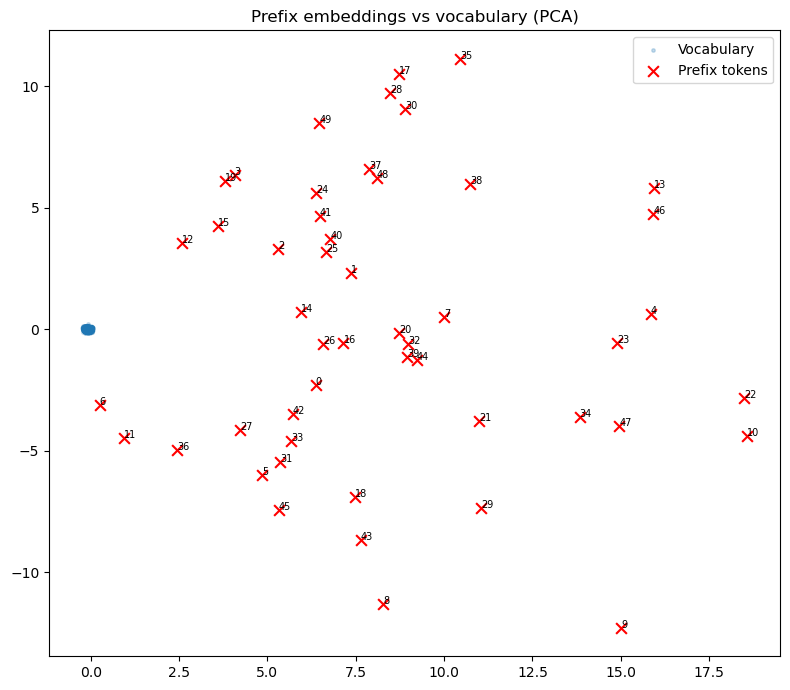

=== AVVIO ANALISI t-SNE ===


g:\Users\Franco\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Impossibile trovare il file specificato
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "g:\Users\Franco\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "g:\Users\Franco\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "g:\Users\Franco\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^

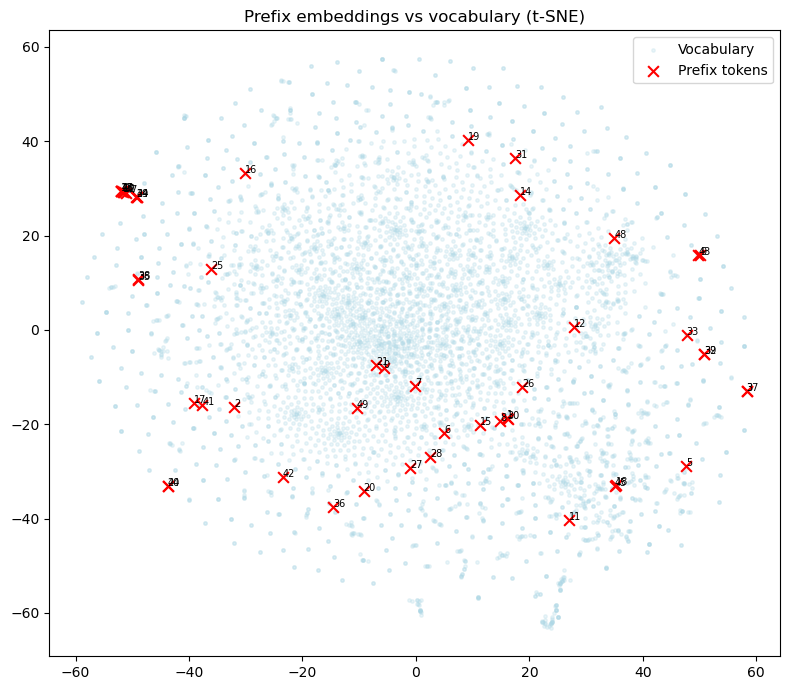

=== DISTRIBUZIONE SIMILARITÀ COSINALE ===


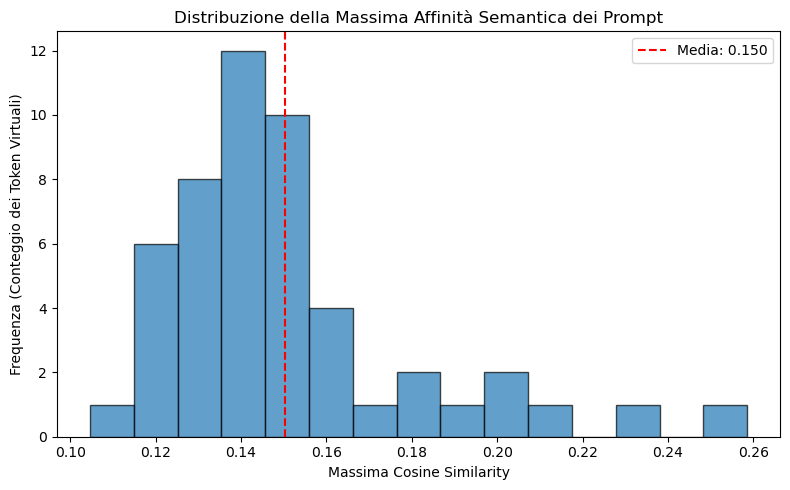

=== ANALISI DELLE MAPPE DI ATTENZIONE ===


BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


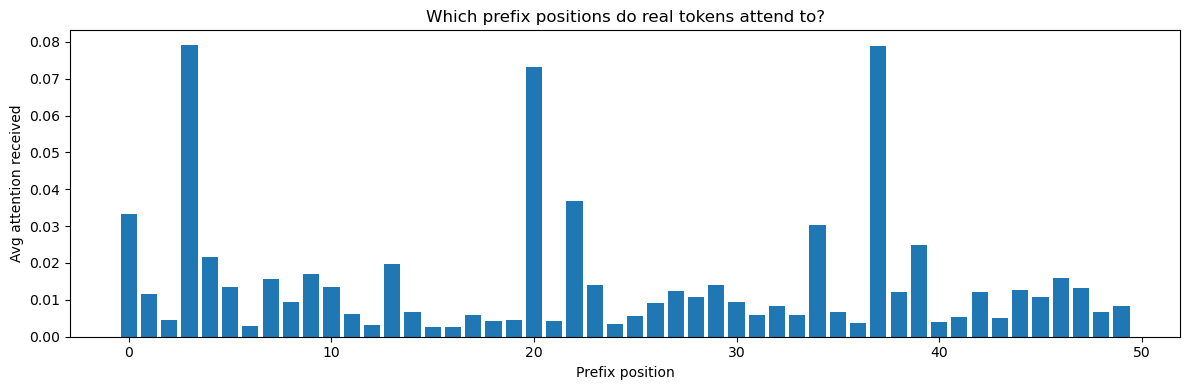

=== CALCOLO DELL'ENTROPIA DI SHANNON ===

Entropia Media dell'Attenzione verso i Prompt: 2.7290


In [ ]:
print("AVVIO ANALISI PCA"BATCH_SIZE)
pca_analysis(model, file_name=file_name)

print("AVVIO ANALISI t-SNE")
tsne_analysis(model, file_name=file_name)

print("DISTRIBUZIONE SIMILARITÀ COSINALE")
cosine_similarity_distribution(model, file_name=file_name)

print("ANALISI DELLE MAPPE DI ATTENZIONE")
attention_analysis(model, val_loader, device, file_name=file_name)

print("CALCOLO DELL'ENTROPIA DI SHANNON")
attention_entropy_analysis(model, val_loader, device)

Converting DataLoader to batch list (this may take a moment)...
Baseline F1: 0.8424
  position 00: F1 = 0.8441  (drop = -0.0017)
  position 01: F1 = 0.8442  (drop = -0.0018)
  position 02: F1 = 0.8405  (drop = +0.0019)
  position 03: F1 = 0.8379  (drop = +0.0045)
  position 04: F1 = 0.8440  (drop = -0.0016)
  position 05: F1 = 0.8426  (drop = -0.0002)
  position 06: F1 = 0.8423  (drop = +0.0001)
  position 07: F1 = 0.8427  (drop = -0.0004)
  position 08: F1 = 0.8470  (drop = -0.0046)
  position 09: F1 = 0.8424  (drop = +0.0000)
  position 10: F1 = 0.8418  (drop = +0.0006)
  position 11: F1 = 0.8351  (drop = +0.0072)
  position 12: F1 = 0.8426  (drop = -0.0002)
  position 13: F1 = 0.8430  (drop = -0.0006)
  position 14: F1 = 0.8413  (drop = +0.0010)
  position 15: F1 = 0.8400  (drop = +0.0024)
  position 16: F1 = 0.8421  (drop = +0.0002)
  position 17: F1 = 0.8443  (drop = -0.0019)
  position 18: F1 = 0.8434  (drop = -0.0010)
  position 19: F1 = 0.8411  (drop = +0.0013)
  position 20: F

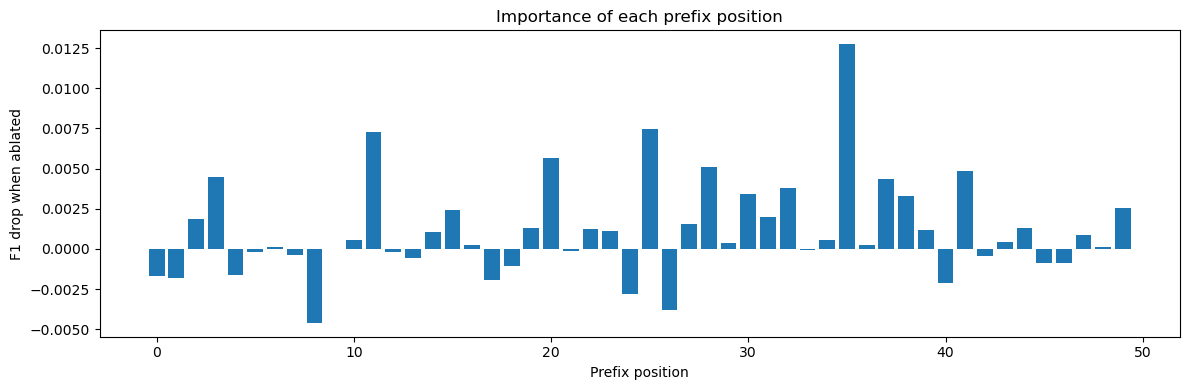

[np.float64(-0.001687289562770311),
 np.float64(-0.0018104089263228929),
 np.float64(0.001870127874285643),
 np.float64(0.004466545581459869),
 np.float64(-0.0016010188577582074),
 np.float64(-0.00018160633394381787),
 np.float64(0.00010998554682761785),
 np.float64(-0.0003550062511272767),
 np.float64(-0.004592265771942605),
 np.float64(6.410895142971995e-06),
 np.float64(0.0005525212078147934),
 np.float64(0.007248934112871974),
 np.float64(-0.00018841196656183),
 np.float64(-0.0005876600113199348),
 np.float64(0.0010415266189273131),
 np.float64(0.0024162642149452296),
 np.float64(0.00023980878495022395),
 np.float64(-0.0019004797400441475),
 np.float64(-0.0010463648484902999),
 np.float64(0.0013310691047042633),
 np.float64(0.005641846712476362),
 np.float64(-0.00013568602739921776),
 np.float64(0.0012467046053150632),
 np.float64(0.0011208188342550773),
 np.float64(-0.0027890372532728414),
 np.float64(0.007492985890171444),
 np.float64(-0.0037941222089095117),
 np.float64(0.001534

In [9]:
ablation_analysis(model, val_loader, device, id_to_tag, file_name=file_name)

Estrazione completata: 50 soft token con dimensionalità 768


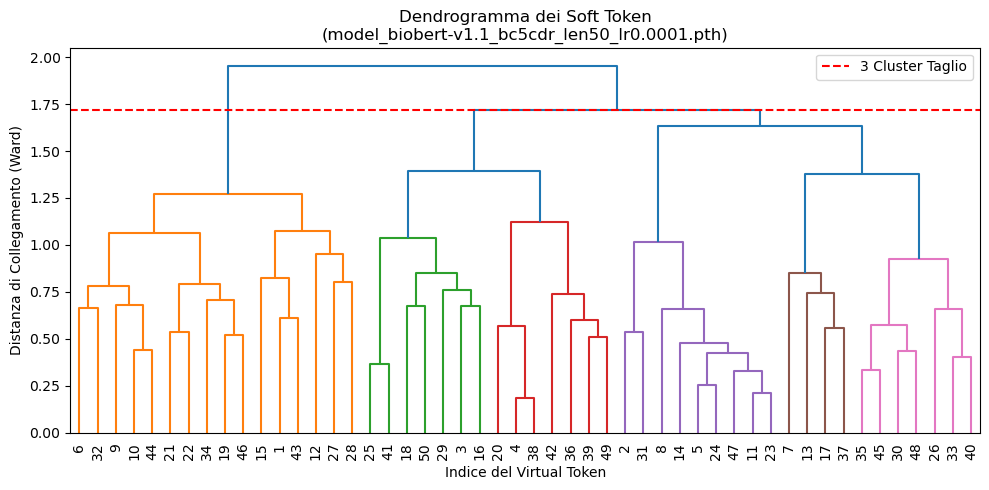

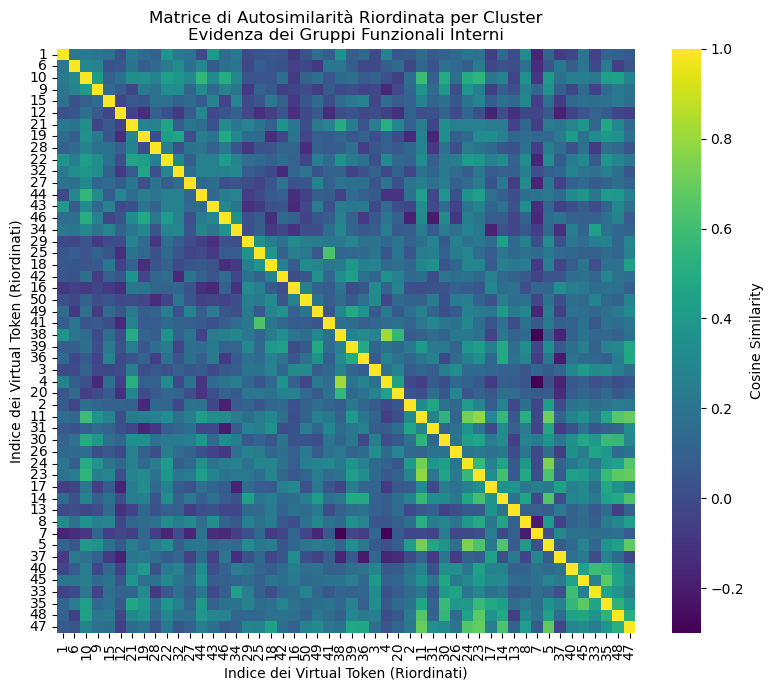


=== COMPOSIZIONE DEI CLUSTER STRUTTURALI ===
Cluster 01 (Dimensione: 16 token): [np.int64(1), np.int64(6), np.int64(9), np.int64(10), np.int64(12), np.int64(15), np.int64(19), np.int64(21), np.int64(22), np.int64(27), np.int64(28), np.int64(32), np.int64(34), np.int64(43), np.int64(44), np.int64(46)]
Cluster 02 (Dimensione: 14 token): [np.int64(3), np.int64(4), np.int64(16), np.int64(18), np.int64(20), np.int64(25), np.int64(29), np.int64(36), np.int64(38), np.int64(39), np.int64(41), np.int64(42), np.int64(49), np.int64(50)]
Cluster 03 (Dimensione: 20 token): [np.int64(2), np.int64(5), np.int64(7), np.int64(8), np.int64(11), np.int64(13), np.int64(14), np.int64(17), np.int64(23), np.int64(24), np.int64(26), np.int64(30), np.int64(31), np.int64(33), np.int64(35), np.int64(37), np.int64(40), np.int64(45), np.int64(47), np.int64(48)]


(array([1, 3, 2, 2, 3, 1, 3, 3, 1, 1, 3, 1, 3, 3, 1, 2, 3, 2, 1, 2, 1, 1,
        3, 3, 2, 3, 1, 1, 2, 3, 3, 1, 3, 1, 3, 2, 3, 2, 2, 3, 2, 2, 1, 1,
        3, 1, 3, 3, 2, 2], dtype=int32),
 array([[ 1.        ,  0.05680927, -0.01104216, ...,  0.09693805,
          0.15315147,  0.02090463],
        [ 0.05680927,  1.        ,  0.07399978, ...,  0.23714608,
          0.16318479,  0.10316727],
        [-0.01104216,  0.07399978,  1.        , ...,  0.2530334 ,
          0.07048824,  0.31489435],
        ...,
        [ 0.09693805,  0.23714608,  0.2530334 , ...,  1.0000001 ,
          0.22204897,  0.10442983],
        [ 0.15315147,  0.16318479,  0.07048824, ...,  0.22204897,
          1.        ,  0.19705224],
        [ 0.02090463,  0.10316727,  0.31489435, ...,  0.10442983,
          0.19705224,  0.9999999 ]], dtype=float32))

In [23]:
cluster_soft_tokens(model, file_name=file_name, n_clusters=3
                    )